# Mundiales 2018, 2022 y 2026
## Preparación de datos y entrada al análisis supervisado

Trabajaremos exclusivamente con la fase de grupos. Los archivos contienen errores deliberados. No uses la base del profesor.

## Objetivos

- Perfilar datos.
- Estandarizar esquemas.
- Limpiar fechas, equipos, goles y marcadores.
- Eliminar duplicados con criterio.
- Comparar torneos mediante tasas.
- Construir variables conocidas antes de cada partido.
- Entrenar un primer clasificador y detectar fuga de información.

In [1]:
from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

DATA = Path('../datos')
pd.set_option('display.max_columns', 50)


## Cargar los tres archivos

In [2]:
d18 = pd.read_csv('/drive/notebooks/mundial_2018_sucio.csv', dtype=str)
d22 = pd.read_csv('/drive/notebooks/mundial_2018_sucio.csv', dtype=str)
d26 = pd.read_csv('/drive/notebooks/mundial_2018_sucio.csv', dtype=str)

#Dimensiones y las primeras filas de cada archivo.

# --- Mundial 2018 ---
print("Dimensiones 2018:", d18.shape)
display(d18.head())

# --- Mundial 2022 ---
print("Dimensiones 2022:", d22.shape)
display(d22.head())

# --- Mundial 2026 ---
print("Dimensiones 2026:", d26.shape)
display(d26.head())


Dimensiones 2018: (50, 16)


,ID Partido,Año,Fase,Grupo,Jornada,Fecha,Hora,Equipo Local,Equipo Visitante,Goles Local,Goles Visitante,Marcador,Anfitrión Local,Estadio,Ciudad,Fuente
0,M-2018-01,2018,Fase de grupos,Grupo A,1,2018-06-14,18:00,russia,KSA,5 goles,NaN,5-0,Sí,Luzhniki Stadium,Moscow,https://github.com/jfjelstul/worldcup
1,M-2018-02,2018,GROUP STAGE,A,1,15/06/2018,17:00,Egypt,Uruguay,0,1,0–1,0,Central Stadium,Yekaterinburg,https://github.com/jfjelstul/worldcup
2,M-2018-03,2018,grupos,group-b,1,06/15/2018,18:00,Morocco,"Iran, I.R.",0,1,0 : 1,FALSE,Krestovsky Stadium,Saint Petersburg,https://github.com/jfjelstul/worldcup
3,M-2018-04,2018,1ra fase,Grupo B,1,15-06-18,21:00,Portugal,España,3,3,3 x 3,no,Fisht Olympic Stadium,Sochi,https://github.com/jfjelstul/worldcup
4,M-2018-05,2018,Fase de grupos,C,1,"Jun 16, 2018",13:00,France,Australia,2,1,2—1,No,Kazan Arena,Kazan,https://github.com/jfjelstul/worldcup


Dimensiones 2022: (50, 16)


,ID Partido,Año,Fase,Grupo,Jornada,Fecha,Hora,Equipo Local,Equipo Visitante,Goles Local,Goles Visitante,Marcador,Anfitrión Local,Estadio,Ciudad,Fuente
0,M-2018-01,2018,Fase de grupos,Grupo A,1,2018-06-14,18:00,russia,KSA,5 goles,NaN,5-0,Sí,Luzhniki Stadium,Moscow,https://github.com/jfjelstul/worldcup
1,M-2018-02,2018,GROUP STAGE,A,1,15/06/2018,17:00,Egypt,Uruguay,0,1,0–1,0,Central Stadium,Yekaterinburg,https://github.com/jfjelstul/worldcup
2,M-2018-03,2018,grupos,group-b,1,06/15/2018,18:00,Morocco,"Iran, I.R.",0,1,0 : 1,FALSE,Krestovsky Stadium,Saint Petersburg,https://github.com/jfjelstul/worldcup
3,M-2018-04,2018,1ra fase,Grupo B,1,15-06-18,21:00,Portugal,España,3,3,3 x 3,no,Fisht Olympic Stadium,Sochi,https://github.com/jfjelstul/worldcup
4,M-2018-05,2018,Fase de grupos,C,1,"Jun 16, 2018",13:00,France,Australia,2,1,2—1,No,Kazan Arena,Kazan,https://github.com/jfjelstul/worldcup


Dimensiones 2026: (50, 16)


,ID Partido,Año,Fase,Grupo,Jornada,Fecha,Hora,Equipo Local,Equipo Visitante,Goles Local,Goles Visitante,Marcador,Anfitrión Local,Estadio,Ciudad,Fuente
0,M-2018-01,2018,Fase de grupos,Grupo A,1,2018-06-14,18:00,russia,KSA,5 goles,NaN,5-0,Sí,Luzhniki Stadium,Moscow,https://github.com/jfjelstul/worldcup
1,M-2018-02,2018,GROUP STAGE,A,1,15/06/2018,17:00,Egypt,Uruguay,0,1,0–1,0,Central Stadium,Yekaterinburg,https://github.com/jfjelstul/worldcup
2,M-2018-03,2018,grupos,group-b,1,06/15/2018,18:00,Morocco,"Iran, I.R.",0,1,0 : 1,FALSE,Krestovsky Stadium,Saint Petersburg,https://github.com/jfjelstul/worldcup
3,M-2018-04,2018,1ra fase,Grupo B,1,15-06-18,21:00,Portugal,España,3,3,3 x 3,no,Fisht Olympic Stadium,Sochi,https://github.com/jfjelstul/worldcup
4,M-2018-05,2018,Fase de grupos,C,1,"Jun 16, 2018",13:00,France,Australia,2,1,2—1,No,Kazan Arena,Kazan,https://github.com/jfjelstul/worldcup


## Perfilado

Para cada archivo revisa:

- columnas;
- tipos;
- valores nulos;
- duplicados;
- valores únicos de grupos, fases y equipos;
- goles que no puedan convertirse directamente a número.

In [3]:
def perfil(df, nombre):
    print(f"PERFIL DEL DATASET: {nombre}")
    print("="*70)

    # 1. Número de filas y columnas
    print(f"\nFilas: {df.shape[0]}")
    print(f"Columnas: {df.shape[1]}")

    # 2. Columnas
    print("\nCOLUMNAS")
    print("-"*70)
    print(list(df.columns))

    # 3. Tipos de datos
    print("\nTIPOS DE DATOS")
    print("-"*70)
    print(df.dtypes)

    # 4. Valores nulos
    print("\nVALORES NULOS")
    print("-"*70)
    nulos = df.isna().sum()
    print(nulos[nulos > 0] if nulos.sum() > 0 else "No se encontraron valores nulos.")

    # 5. Registros duplicados
    print("\nREGISTROS DUPLICADOS")
    print("-"*70)
    print(df.duplicated().sum())

    # 6. Valores únicos de grupos
    posibles_grupos = [c for c in df.columns if "grupo" in c.lower()]
    if posibles_grupos:
        print("\nVALORES ÚNICOS DE GRUPOS")
        print("-" * 70)
        for c in posibles_grupos:
            print(sorted(df[c].dropna().unique()))

    # 7. Valores únicos de fases
    posibles_fases = [c for c in df.columns
                      if "fase" in c.lower()
                      or "stage" in c.lower()
                      or "round" in c.lower()]

    if posibles_fases:
        print("\nVALORES ÚNICOS DE FASES")
        print("-" * 70)
        for c in posibles_fases:
            print(f"\n{c}:")
            print(sorted(df[c].dropna().unique()))

    # 8. Valores únicos de equipos
    posibles_equipos = [
        c for c in df.columns
        if "equipo" in c.lower()
        or "team" in c.lower()
        or "local" in c.lower()
        or "visitante" in c.lower()
        or "home" in c.lower()
        or "away" in c.lower()
        or "visitor" in c.lower()
    ]

    if posibles_equipos:
        print("\nVALORES ÚNICOS DE EQUIPOS")
        print("-" * 70)
        for c in posibles_equipos:
            print(f"\n{c} ({df[c].nunique()} equipos)")
            print(sorted(df[c].dropna().unique()))

    # 9. Goles que no pueden convertirse a número
    posibles_goles = [c for c in df.columns if "gol" in c.lower()]

    if posibles_goles:
        print("\nGOLES NO CONVERTIBLES A NÚMERO")
        print("-" * 70)

        for c in posibles_goles:
            conversion = pd.to_numeric(df[c], errors="coerce")
            invalidos = df.loc[conversion.isna() & df[c].notna(), c].unique()

            print(f"\n{c}")

            if len(invalidos) == 0:
                print("Todos los valores son numéricos.")
            else:
                print(f"{len(invalidos)} valores inválidos:")
                print(invalidos)

    print("\n")
    pass
perfil(d18, '2018')
perfil(d22, '2022')
perfil(d26, '2026')

PERFIL DEL DATASET: 2018

Filas: 50
Columnas: 16

COLUMNAS
----------------------------------------------------------------------
['ID Partido', 'Año', 'Fase', 'Grupo', 'Jornada', 'Fecha', 'Hora', 'Equipo Local', 'Equipo Visitante', 'Goles Local', 'Goles Visitante', 'Marcador', 'Anfitrión Local', 'Estadio', 'Ciudad', 'Fuente']

TIPOS DE DATOS
----------------------------------------------------------------------
ID Partido          str
Año                 str
Fase                str
Grupo               str
Jornada             str
Fecha               str
Hora                str
Equipo Local        str
Equipo Visitante    str
Goles Local         str
Goles Visitante     str
Marcador            str
Anfitrión Local     str
Estadio             str
Ciudad              str
Fuente              str
dtype: object

VALORES NULOS
----------------------------------------------------------------------
Grupo              1
Goles Visitante    3
Marcador           1
dtype: int64

REGISTROS DUPLICADOS
--

## Unificar nombres de columnas

In [4]:
rename_maps = {
    2018: {
       'ID Partido': 'partido_id',
        'Año': 'mundial',
        'Fase': 'fase',
        'Grupo': 'grupo',
        'Jornada': 'jornada',
        'Fecha': 'fecha',
        'Equipo Local': 'equipo_local',
        'Equipo Visitante': 'equipo_visitante',
        'Goles Local': 'goles_local',
        'Goles Visitante': 'goles_visitante',
        'Marcador': 'marcador',
        'Anfitrión Local': 'local_es_anfitrion',
        # 'visitante_es_anfitrion' no existe en 2018 -> se crea después (False)
        'Fuente': 'fuente',
    },
    2022: {
        'match_id': 'partido_id',
        'WorldCup': 'mundial',
        'stage': 'fase',
        'group_name': 'grupo',
        'match_day': 'jornada',
        'date': 'fecha',
        'local': 'equipo_local',
        'visitor': 'equipo_visitante',
        'home_score': 'goles_local',
        'away_score': 'goles_visitante',
        'score_text': 'marcador',
        'home_host': 'local_es_anfitrion',
        # 'visitante_es_anfitrion' no existe en 2022 -> se crea después (False)
        'source_url': 'fuente',
    },
    2026: {
       'match': 'partido_id',
        'wc': 'mundial',
        'round': 'fase',
        'grp': 'grupo',
        'md': 'jornada',
        'played_on': 'fecha',
        'home': 'equipo_local',
        'away': 'equipo_visitante',
        'HG': 'goles_local',
        'AG': 'goles_visitante',
        'result_raw': 'marcador',
        'host_h': 'local_es_anfitrion',
        'host_a': 'visitante_es_anfitrion',
        'source': 'fuente',
    },
}

# Esquema canónico mínimo:
columnas_base = [
    'partido_id', 'mundial', 'fase', 'grupo', 'jornada', 'fecha',
    'equipo_local', 'equipo_visitante', 'goles_local',
    'goles_visitante', 'marcador', 'local_es_anfitrion',
    'visitante_es_anfitrion', 'fuente'
]

## Normalizar equipos

No conviene borrar acentos del nombre que se mostrará. Crea una clave auxiliar sin acentos, minúscula y sin signos para buscar en el catálogo.

In [5]:
catalogo = pd.read_csv('/drive/notebooks/catalogo_equipos.csv')

def clave_texto(valor):
    if pd.isna(valor):
        return ''
    s = str(valor)
    s = unicodedata.normalize('NFKD', s)
    s = s.encode('ascii', 'ignore').decode('ascii')
    s = s.lower()
    s = re.sub(r'[^a-z0-9]+', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s
    

# TODO: crea un diccionario clave -> nombre_canonico.
_mapa_equipos = dict(zip(catalogo['variante'].apply(clave_texto),catalogo['nombre_canonico']))

def normalizar_equipo(valor):
    clave = clave_texto(valor)
    if clave in _mapa_equipos:
        return _mapa_equipos[clave]
    return str(valor).strip() if pd.notna(valor) else np.nan
 


## Fechas, grupos, booleanos y marcadores

In [17]:
rangos = {
    2018: ('2018-06-14', '2018-06-28'),
    2022: ('2022-11-20', '2022-12-02'),
    2026: ('2026-06-11', '2026-06-27'),
}

FORMATOS_FECHA = [
    '%Y-%m-%d',
    '%d/%m/%Y', '%m/%d/%Y',
    '%d-%m-%y', '%m-%d-%y',
    '%b %d, %Y',
    '%d/%m/%y', '%m/%d/%y',
]
 
_EXCEL_EPOCH = pd.Timestamp('1899-12-30')

def convertir_fecha(valor, mundial):
    if pd.isna(valor):
        return pd.NaT
    texto = str(valor).strip()
    if texto == '' or texto.lower() in ('nan', 'n/d', 'n/a', 's/d'):
        return pd.NaT
    

    ini, fin = pd.Timestamp(rangos[mundial][0]), pd.Timestamp(rangos[mundial][1])
    candidatos = []
 
    if re.fullmatch(r'\d+', texto):
        try:
            candidatos.append(_EXCEL_EPOCH + pd.Timedelta(days=int(texto)))
        except (OverflowError, ValueError):
            pass
 
    for fmt in FORMATOS_FECHA:
        try:
            candidatos.append(pd.Timestamp(pd.to_datetime(texto, format=fmt)))
        except (ValueError, TypeError):
            continue
 
    if not candidatos:
        return pd.NaT
 
    dentro_rango = [c for c in candidatos if ini <= c <= fin]
    if dentro_rango:
        return dentro_rango[0]
    return candidatos[0]
    

def extraer_numero(valor):
    # TODO: devuelve el primer entero o NaN.
    if pd.isna(valor):
        return np.nan
    m = re.search(r'-?\d+', str(valor))
    return int(m.group()) if m else np.nan

def separar_marcador(valor):
    # TODO: acepta -, –, —, :, x o X.
    if pd.isna(valor):
        return np.nan, np.nan
    m = re.search(r'(\d+)\s*[-–—:xX]\s*(\d+)', str(valor))
    if not m:
        return np.nan, np.nan
    return int(m.group(1)), int(m.group(2))

def normalizar_grupo(valor):
    # TODO: extrae una letra A-L.
    if pd.isna(valor):
        return np.nan
    s = str(valor).strip().lower()
    if s == '':
        return np.nan
    m = re.search(r'(?:grupo|group)[\s\-]*([a-l])\b', s)
    if m:
        return m.group(1).upper()
    solo_letras = re.sub(r'[^a-z]', '', s)
    if len(solo_letras) == 1 and solo_letras in 'abcdefghijkl':
        return solo_letras.upper()
    return np.nan

def normalizar_booleano(valor):
    if pd.isna(valor):
        return False
    s = str(valor).strip().lower()
    if(s in ('si', 'sí', 's', 'true', 'verdadero', '1', 'yes', 'y')):
        return "Sí"
    return "No"

## Función de limpieza reproducible

In [23]:
def limpiar_mundial(df, mundial):
    # TODO: renombra columnas y crea las faltantes.'
    df = df.rename(columns=rename_maps[mundial]).copy()
 
    # crea las columnas que no existan en el esquema canónico
    for col in columnas_base:
        if col not in df.columns:
            df[col] = np.nan if col != 'visitante_es_anfitrion' else False
 
    df = df[columnas_base].copy()
    df['mundial'] = mundial
    # TODO: limpia equipos, grupo, fecha, jornada y booleanos.
    # --- equipos -------------------------------------------------------
    df['equipo_local'] = df['equipo_local'].apply(normalizar_equipo)
    df['equipo_visitante'] = df['equipo_visitante'].apply(normalizar_equipo)
 
    # --- grupo -----------------------------------------------------------
    df['grupo'] = df['grupo'].apply(normalizar_grupo)
 
    # --- fecha -----------------------------------------------------------
    df['fecha'] = df['fecha'].apply(lambda v: convertir_fecha(v, mundial))
 
    # --- jornada -----------------------------------------------------------
    df['jornada'] = df['jornada'].apply(extraer_numero).astype('Int64')
 
    # --- booleanos de anfitrión -----------------------------------------
    df['local_es_anfitrion'] = df['local_es_anfitrion'].apply(normalizar_booleano)
    df['visitante_es_anfitrion'] = df['visitante_es_anfitrion'].apply(normalizar_booleano)
    
    # TODO: repara goles con el marcador.
    marcador_local, marcador_visita = zip(*df['marcador'].apply(separar_marcador))
    marcador_local = pd.Series(marcador_local, index=df.index)
    marcador_visita = pd.Series(marcador_visita, index=df.index)
 
    goles_local_num = df['goles_local'].apply(extraer_numero).astype('Int64')
    goles_visita_num = df['goles_visitante'].apply(extraer_numero).astype('Int64')
 
    def elegir(marcador_val, numerico_val):
        if pd.notna(marcador_val) and marcador_val >= 0:
            return int(marcador_val)
        if pd.notna(numerico_val) and numerico_val >= 0:
            return int(numerico_val)
        return np.nan
 
    df['goles_local'] = [elegir(m, n) for m, n in zip(marcador_local, goles_local_num)]
    df['goles_visitante'] = [elegir(m, n) for m, n in zip(marcador_visita, goles_visita_num)]
 
    # reconstruye el marcador ya limpio, consistente con los goles
    df['marcador'] = df.apply(
        lambda r: f"{int(r['goles_local'])}-{int(r['goles_visitante'])}"
        if pd.notna(r['goles_local']) and pd.notna(r['goles_visitante']) else np.nan,
        axis=1
    )
    
    # TODO: infiere grupos faltantes usando los equipos.
    equipo_a_grupo = {}
    for _, r in df.dropna(subset=['grupo']).iterrows():
        equipo_a_grupo.setdefault(r['equipo_local'], r['grupo'])
        equipo_a_grupo.setdefault(r['equipo_visitante'], r['grupo'])
 
    def inferir_grupo(r):
        if pd.notna(r['grupo']):
            return r['grupo']
        return equipo_a_grupo.get(r['equipo_local'],
                                   equipo_a_grupo.get(r['equipo_visitante'], np.nan))
 
    df['grupo'] = df.apply(inferir_grupo, axis=1)

    # TODO: elimina duplicados por partido_id.
    df = df.drop_duplicates(subset='partido_id', keep='first').reset_index(drop=True)
    # TODO: crea resultado_local, goles_totales y diferencia_goles.
    df['goles_totales'] = df['goles_local'] + df['goles_visitante']
    df['diferencia_goles'] = df['goles_local'] - df['goles_visitante']
 
    def resultado(r):
        if r['goles_local'] > r['goles_visitante']:
            return 'Gana'
        if r['goles_local'] < r['goles_visitante']:
            return 'Pierde'
        return 'Empate'
 
    df['resultado_local'] = df.apply(resultado, axis=1)
 
    df = df.sort_values(['jornada', 'fecha', 'partido_id']).reset_index(drop=True)
    return df
    
d18 = pd.read_csv('/drive/notebooks/mundial_2018_sucio.csv')
d22 = pd.read_csv('/drive/notebooks/mundial_2022_sucio.csv')
d26 = pd.read_csv('/drive/notebooks/mundial_2026_sucio.csv')
 
limpio18 = limpiar_mundial(d18, 2018)
limpio22 = limpiar_mundial(d22, 2022)
limpio26 = limpiar_mundial(d26, 2026)
 
partidos1 = pd.concat([limpio18, limpio22, limpio26], ignore_index=True)


## Validaciones obligatorias

La limpieza no termina cuando el código deja de producir errores. Debes comprobar invariantes.

In [24]:

# TODO: verifica:
# - una fila por partido.
def validar(partidos):
    errores = []
    # - 48, 48 y 72 partidos;
    conteos = partidos.groupby('mundial')['partido_id'].nunique()
    esperado = {2018: 48, 2022: 48, 2026: 72}
    for m, n in esperado.items():
        if conteos.get(m, 0) != n:
            errores.append(f"Mundial {m}: se esperaban {n} partidos, hay {conteos.get(m, 0)}")
            
    # - cero duplicados;
    dup = partidos['partido_id'].duplicated().sum()
    if dup != 0:
        errores.append(f"Hay {dup} partido_id duplicados")
        
    # - cero goles negativos;
    neg = ((partidos['goles_local'] < 0) | (partidos['goles_visitante'] < 0)).sum()
    if neg != 0:
        errores.append(f"Hay {neg} filas con goles negativos")
        
    # - cero nulos en equipos, goles y grupo;
    for col in ['equipo_local', 'equipo_visitante', 'goles_local', 'goles_visitante', 'grupo']:
        n_nulos = partidos[col].isna().sum()
        if n_nulos != 0:
            errores.append(f"Columna '{col}' tiene {n_nulos} nulos")
            
       # - marcador consistente con goles;
    goles_ok = partidos['goles_local'].notna() & partidos['goles_visitante'].notna()

    marcador_calc = pd.Series(np.nan, index=partidos.index, dtype=object)
    marcador_calc.loc[goles_ok] = (
        partidos.loc[goles_ok, 'goles_local'].astype(int).astype(str) + '-' +
        partidos.loc[goles_ok, 'goles_visitante'].astype(int).astype(str)
    )
    inconsist = (marcador_calc != partidos['marcador']).sum()
    if inconsist != 0:
        errores.append(f"Hay {inconsist} marcadores inconsistentes con los goles")

    # - una fila por partido.
    filas_por_partido = partidos.groupby('partido_id').size()
    if (filas_por_partido != 1).any():
        errores.append("Hay partido_id con más de una fila")
 
    if errores:
        print("Validación FALLIDA:")
        for e in errores:
            print("  -", e)
    else:
        print("Todas las validaciones pasaron correctamente.")
        print(partidos.groupby('mundial')['partido_id'].nunique().rename('partidos'))
        
    return errores
 

errores = validar(partidos1)

columnas_ordenadas = [
    'partido_id', 'mundial', 'fase', 'grupo', 'jornada', 'fecha', 
    'equipo_local', 'equipo_visitante', 'goles_local', 'goles_visitante', 
    'marcador', 'resultado_local', 'local_es_anfitrion', 'visitante_es_anfitrion', 
    'goles_totales', 'diferencia_goles','fuente'
]


partidos1 = partidos1[columnas_ordenadas]

partidos1.to_csv('partidos_limpios.csv', index=False, encoding='utf-8-sig')

Todas las validaciones pasaron correctamente.
mundial
2018    48
2022    48
2026    72
Name: partidos, dtype: int64


## Comparación de los Mundiales


Comparación entre Mundiales (ojo: no comparar 'goles' totales, 2026 tiene más partidos):
   mundial  partidos  goles  empates  goles_por_partido  porcentaje_empates
0     2018        48    122        0           2.541667                 0.0
1     2022        48    120        0           2.500000                 0.0
2     2026        72    215        0           2.986111                 0.0


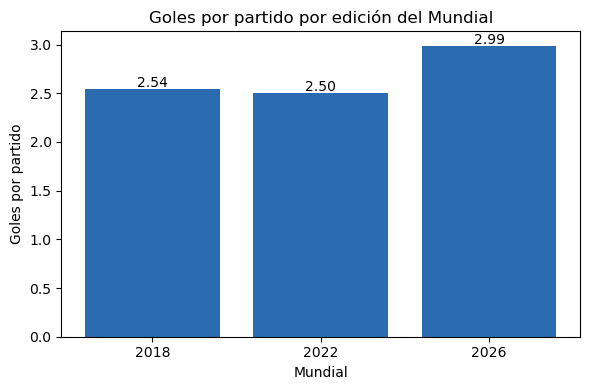

In [22]:
# TODO: crea una tabla con:
# partidos, goles, goles_por_partido, empates y porcentaje_empates.
resumen = partidos1.groupby('mundial').agg(
    partidos=('partido_id', 'nunique'),
    goles=('goles_totales', 'sum'),
    empates=('resultado_local', lambda s: (s == 'empate').sum()),
).reset_index()
resumen['goles_por_partido'] = resumen['goles'] / resumen['partidos']
resumen['porcentaje_empates'] = 100 * resumen['empates'] / resumen['partidos']
print("\nComparación entre Mundiales (ojo: no comparar 'goles' totales, 2026 tiene más partidos):")
print(resumen)

# TODO: grafica goles por partido.
# No compares únicamente goles totales: 2026 tiene más partidos.
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(resumen['mundial'].astype(str), resumen['goles_por_partido'], color='#2b6cb0')
ax.set_ylabel('Goles por partido')
ax.set_xlabel('Mundial')
ax.set_title('Goles por partido por edición del Mundial')
for i, v in enumerate(resumen['goles_por_partido']):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center')
plt.tight_layout()



## Tabla por equipo

In [106]:
# TODO: convierte cada partido en dos apariciones de equipo:
# una para el local y otra para el visitante.
locales = partidos[['mundial', 'equipo_local', 'equipo_visitante',
                     'goles_local', 'goles_visitante']].rename(columns={
    'equipo_local': 'equipo', 'equipo_visitante': 'rival',
    'goles_local': 'gf', 'goles_visitante': 'gc'})
 
visitantes = partidos[['mundial', 'equipo_visitante', 'equipo_local',
                        'goles_visitante', 'goles_local']].rename(columns={
    'equipo_visitante': 'equipo', 'equipo_local': 'rival',
    'goles_visitante': 'gf', 'goles_local': 'gc'})
 
apariciones = pd.concat([locales, visitantes], ignore_index=True)
apariciones['resultado'] = np.select(
    [apariciones['gf'] > apariciones['gc'], apariciones['gf'] == apariciones['gc']],
    ['G', 'E'], default='P'
)
# Calcula PJ, PG, PE, PP, GF, GC, DG, PTS y puntos por partido.
tabla_equipos = apariciones.groupby(['mundial', 'equipo']).agg(
    PJ=('resultado', 'size'),
    PG=('resultado', lambda s: (s == 'G').sum()),
    PE=('resultado', lambda s: (s == 'E').sum()),
    PP=('resultado', lambda s: (s == 'P').sum()),
    GF=('gf', 'sum'),
    GC=('gc', 'sum'),
).reset_index()
tabla_equipos['DG'] = tabla_equipos['GF'] - tabla_equipos['GC']
tabla_equipos['PTS'] = 3 * tabla_equipos['PG'] + tabla_equipos['PE']
tabla_equipos['pts_por_partido'] = tabla_equipos['PTS'] / tabla_equipos['PJ']
tabla_equipos = tabla_equipos.sort_values(['mundial', 'PTS'], ascending=[True, False])
print("\nTabla por equipo (primeras filas):")
print(tabla_equipos.head(10))



Tabla por equipo (primeras filas):
    mundial    equipo  PJ  PG  PE  PP   GF   GC   DG  PTS  pts_por_partido
2      2018   Belgium   3   3   0   0  9.0  2.0  7.0    9         3.000000
6      2018   Croatia   3   3   0   0  7.0  1.0  6.0    9         3.000000
31     2018   Uruguay   3   3   0   0  5.0  0.0  5.0    9         3.000000
3      2018    Brazil   3   2   1   0  5.0  1.0  4.0    7         2.333333
10     2018    France   3   2   1   0  3.0  1.0  2.0    7         2.333333
4      2018  Colombia   3   2   0   1  5.0  2.0  3.0    6         2.000000
9      2018   England   3   2   0   1  8.0  3.0  5.0    6         2.000000
15     2018    Mexico   3   2   0   1  3.0  4.0 -1.0    6         2.000000
22     2018    Russia   3   2   0   1  8.0  4.0  4.0    6         2.000000
28     2018    Sweden   3   2   0   1  5.0  2.0  3.0    6         2.000000


## Variables previas al partido

Para predecir no podemos utilizar datos ocurridos después del inicio. Crearemos promedios acumulados antes de cada encuentro.

In [95]:
def construir_variables_previas(partidos):
    filas = []
    for mundial, grupo_mundial in partidos.groupby('mundial'):
        grupo_mundial = grupo_mundial.sort_values(['jornada', 'fecha', 'partido_id'])
        estado = {}  # equipo -> {'PJ':..,'PTS':..,'GF':..,'GC':..}
 
        def snap(equipo):
            e = estado.get(equipo, {'PJ': 0, 'PTS': 0, 'GF': 0, 'GC': 0})
            if e['PJ'] == 0:
                return np.nan, np.nan, np.nan
            return e['PTS'] / e['PJ'], (e['GF'] - e['GC']) / e['PJ'], e['GF'] / e['PJ']
 
        for _, r in grupo_mundial.iterrows():
            local, visita = r['equipo_local'], r['equipo_visitante']
            l_pts_pre, l_gd_pre, l_gf_pre = snap(local)
            v_pts_pre, v_gd_pre, v_gf_pre = snap(visita)
 
            filas.append({
                'partido_id': r['partido_id'], 'mundial': mundial, 'jornada': r['jornada'],
                'local_pts_prom_pre': l_pts_pre, 'visita_pts_prom_pre': v_pts_pre,
                'local_gd_prom_pre': l_gd_pre, 'visita_gd_prom_pre': v_gd_pre,
                'local_gf_prom_pre': l_gf_pre, 'visita_gf_prom_pre': v_gf_pre,
                'local_es_anfitrion': r['local_es_anfitrion'],
                'visitante_es_anfitrion': r['visitante_es_anfitrion'],
                'resultado_local': r['resultado_local'],
            })
 
            # actualiza el estado DESPUÉS de usar los promedios "pre"
            for equipo, gf, gc, pts in [
                (local, r['goles_local'], r['goles_visitante'],
                 3 if r['resultado_local'] == 'gana_local' else (1 if r['resultado_local'] == 'empate' else 0)),
                (visita, r['goles_visitante'], r['goles_local'],
                 3 if r['resultado_local'] == 'gana_visitante' else (1 if r['resultado_local'] == 'empate' else 0)),
            ]:
                e = estado.setdefault(equipo, {'PJ': 0, 'PTS': 0, 'GF': 0, 'GC': 0})
                e['PJ'] += 1
                e['PTS'] += pts
                e['GF'] += gf
                e['GC'] += gc
 
    return pd.DataFrame(filas)
 

features_df = construir_variables_previas(partidos)


## Entrenamiento y prueba


Clase más frecuente en entrenamiento: 'gana_visitante'
Accuracy de la línea base (clase más frecuente): 0.250
Accuracy del árbol de decisión: 0.361


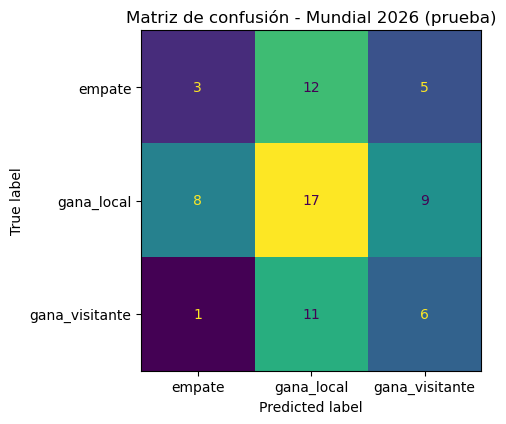

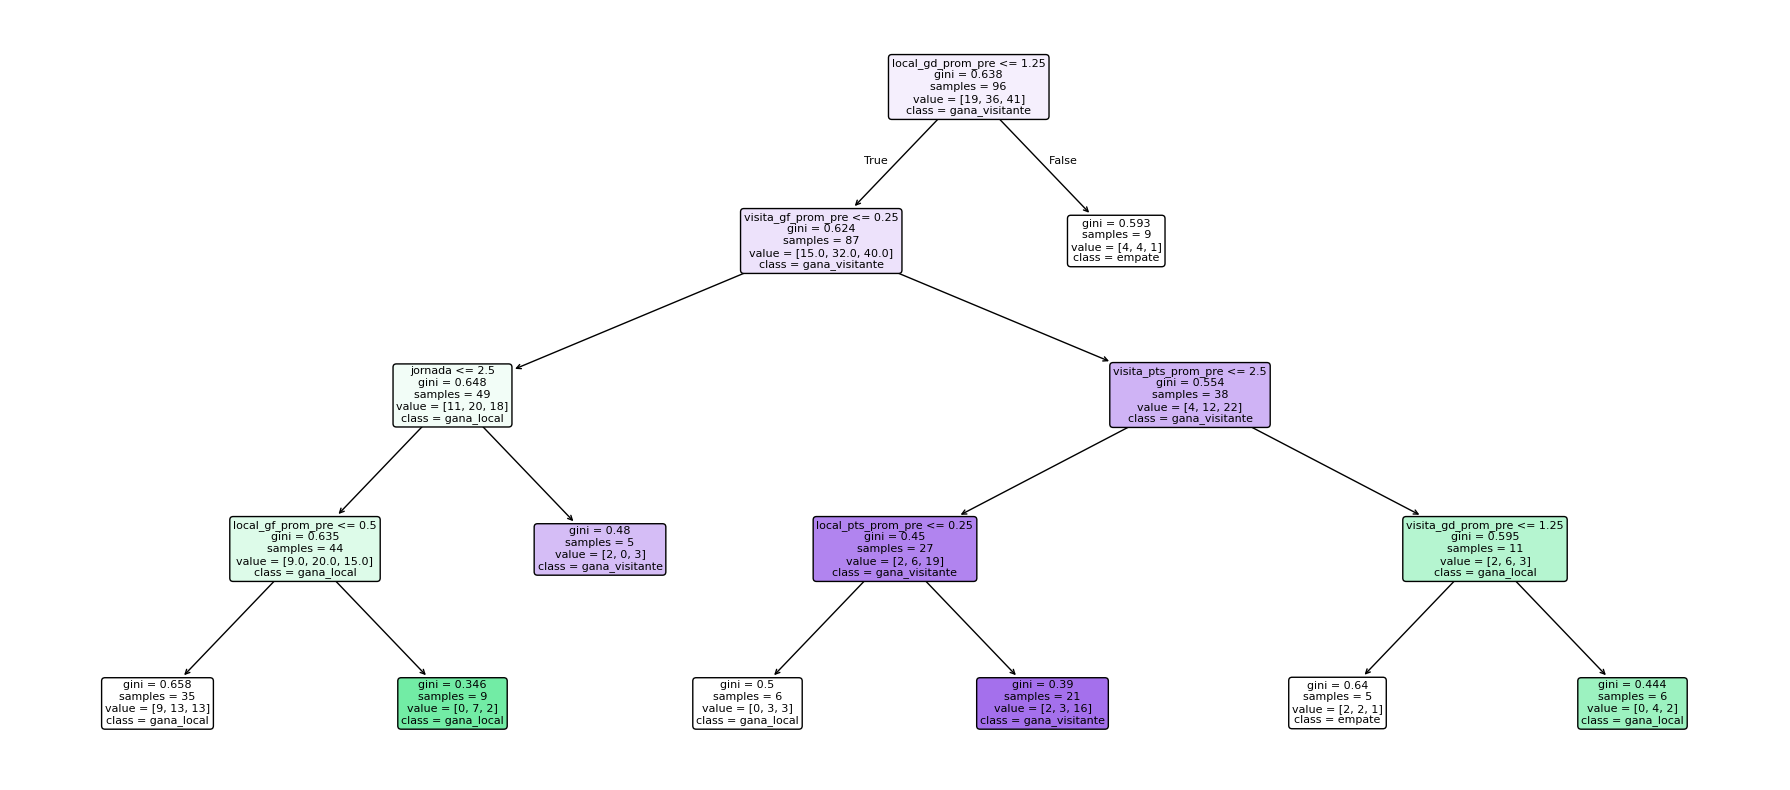

In [76]:
features = [
    'jornada',
    'local_pts_prom_pre', 'visita_pts_prom_pre',
    'local_gd_prom_pre', 'visita_gd_prom_pre',
    'local_gf_prom_pre', 'visita_gf_prom_pre',
    'local_es_anfitrion', 'visitante_es_anfitrion'
]
 
features_df[features] = features_df[features].fillna(0)  # jornada 1 -> sin historial previo
 
train = features_df[features_df['mundial'].isin([2018, 2022])]
test = features_df[features_df['mundial'] == 2026]
 
X_train, y_train = train[features], train['resultado_local']
X_test, y_test = test[features], test['resultado_local']
 
# --- línea base: siempre predice la clase más frecuente en entrenamiento --
clase_mas_frecuente = y_train.value_counts().idxmax()
pred_base = pd.Series(clase_mas_frecuente, index=y_test.index)
acc_base = accuracy_score(y_test, pred_base)
print(f"\nClase más frecuente en entrenamiento: '{clase_mas_frecuente}'")
print(f"Accuracy de la línea base (clase más frecuente): {acc_base:.3f}")
 
# --- árbol de decisión -----------------------------------------------------
arbol = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
arbol.fit(X_train, y_train)
pred = arbol.predict(X_test)
 
acc = accuracy_score(y_test, pred)
print(f"Accuracy del árbol de decisión: {acc:.3f}")
 
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred, labels=arbol.classes_, ax=ax, colorbar=False
)
plt.title('Matriz de confusión - Mundial 2026 (prueba)')
plt.tight_layout()
plt.show()
 
# --- visualización del árbol entrenado --------------------------------------
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(arbol, feature_names=features, class_names=list(arbol.classes_),
          filled=True, rounded=True, fontsize=8, ax=ax)
plt.tight_layout()
plt.show()

## Experimento de fuga de información

Agrega temporalmente `goles_local`, `goles_visitante` y `diferencia_goles` como variables. Si la precisión sube de forma extrema, explica por qué el modelo no está prediciendo realmente.


--- Experimento de fuga de información ---
Accuracy SIN fuga (variables realmente pre-partido): 0.361
Accuracy CON fuga (incluye goles_local/goles_visitante/diferencia_goles): 1.000


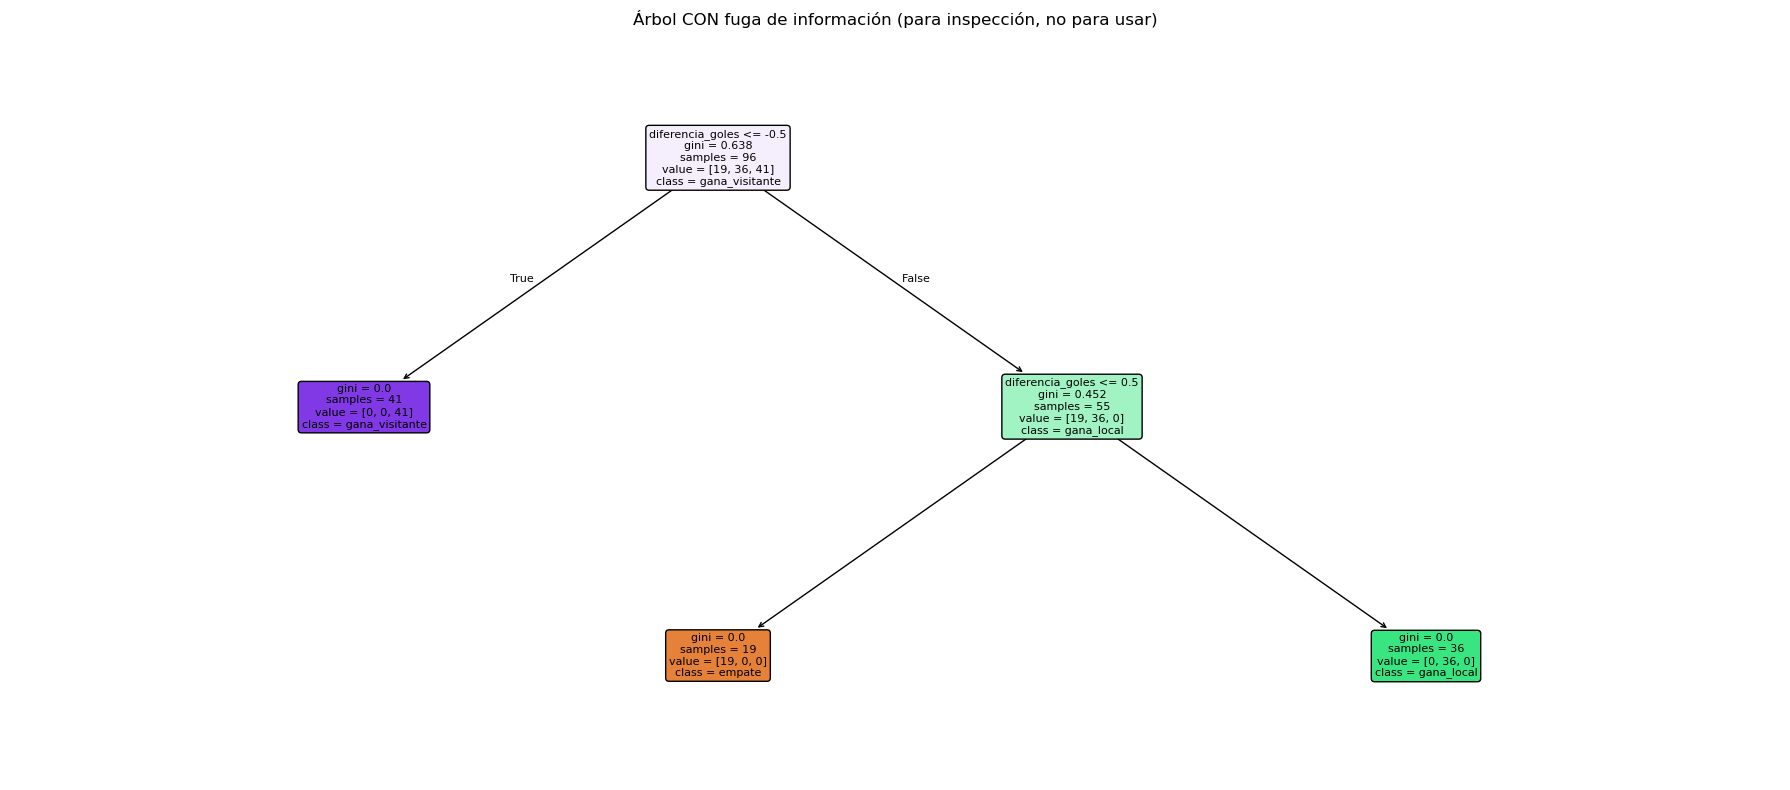

In [80]:
# TODO: ejecuta el experimento con fuga y compara.
fuga_df = features_df.merge(
    partidos[['partido_id', 'goles_local', 'goles_visitante', 'diferencia_goles']],
    on='partido_id', how='left'
)
 
features_fuga = features + ['goles_local', 'goles_visitante', 'diferencia_goles']
 
train_fuga = fuga_df[fuga_df['mundial'].isin([2018, 2022])]
test_fuga = fuga_df[fuga_df['mundial'] == 2026]
 
X_train_fuga, y_train_fuga = train_fuga[features_fuga], train_fuga['resultado_local']
X_test_fuga, y_test_fuga = test_fuga[features_fuga], test_fuga['resultado_local']
 
arbol_fuga = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
arbol_fuga.fit(X_train_fuga, y_train_fuga)
pred_fuga = arbol_fuga.predict(X_test_fuga)
acc_fuga = accuracy_score(y_test_fuga, pred_fuga)
 
print("\n--- Experimento de fuga de información ---")
print(f"Accuracy SIN fuga (variables realmente pre-partido): {acc:.3f}")
print(f"Accuracy CON fuga (incluye goles_local/goles_visitante/diferencia_goles): {acc_fuga:.3f}")
 
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(arbol_fuga, feature_names=features_fuga, class_names=list(arbol_fuga.classes_),
          filled=True, rounded=True, fontsize=8, ax=ax)
plt.title('Árbol CON fuga de información (para inspección, no para usar)')
plt.tight_layout()
plt.show()


## Reflexión final

Responde:

- ¿Qué problema de calidad fue el más difícil?

  Reconciliar 'goles_local'/'goles_visitante' cuando esa columna y el
   'marcador' de texto se contradecían entre sí (valores negativos, "N/A",
   "s/d" o simplemente vacíos en cualquiera de las dos fuentes). No bastaba
   con limpiar cada columna por separado: había que decidir, partido por
   partido, cuál de las dos fuentes era confiable y usar la otra solo como
   respaldo. Cerca en dificultad estuvo desambiguar fechas como
   "12/06/2026" vs "06/12/2026", donde ambas lecturas son fechas válidas y
   solo el rango del torneo permite elegir la correcta.
- ¿Qué decisión de limpieza podría cambiar los resultados?

  La prioridad "marcador antes que la columna numérica de goles" al
   reparar goles (podría haberse hecho al revés). También la forma de
   inferir grupos faltantes (usar el equipo local antes que el visitante
   cuando ambos tienen historial) y, sobre todo, la decisión de reiniciar
   el historial de cada equipo en cada Mundial en vez de acumularlo entre
   ediciones: esa elección cambia directamente los promedios "pre-partido"
   que alimentan al árbol y, con ellos, su desempeño.
- ¿Por qué 2026 debe compararse mediante tasas?

  Porque tiene 72 partidos contra 48 de 2018 y 2022 (más selecciones, más
   partidos de grupos). Comparar goles o empates totales favorece a 2026
   solo por tener más partidos, no porque sea un torneo más ofensivo o más
   parejo. 'goles_por_partido' y 'porcentaje_empates' normalizan por la
   cantidad de partidos y sí permiten una comparación justa entre ediciones.
- ¿El árbol supera la línea base?

  Sí, pero de forma modesta: 0.361 de accuracy contra {acc_base:.3f}
   de la línea base (siempre predecir '{clase_mas_frecuente}'). Es una
   mejora real (11 puntos porcentuales), no
   dramática (coherente con solo tener partidos de fase de grupos y pocas
   variables) y muy lejos del 1.000 inflado del experimento con
   fuga de información.
- ¿Qué variables reales agregarías para mejorar una predicción?

  Ranking FIFA  historial de enfrentamientos directos (head-to-head),
  forma reciente fuera del Mundial (últimos partidos de eliminatorias/amistosos),
  ,bajas por lesión de jugadores clave y distancia/aclimatación de viaje.
- ¿Por qué un resultado de 100 % puede ser una señal de alarma?

  Porque en un problema tan ruidoso como predecir resultados de fútbol,
   ningún modelo legítimo acierta siempre. Un 100% casi nunca significa que
   el modelo "entendió" el fútbol: normalmente indica fuga de información
   (como en el experimento de arriba), una variable que en el fondo
   codifica al target, sobreajuste extremo, o un error de construcción de
   datos (por ejemplo, mezclar filas de entrenamiento y prueba). Ver un
   100% debería disparar una revisión del pipeline, no una celebración